# Mô phỏng & Đánh giá Thuật toán GMM-HMM Phân cấp (Xie et al. 2025)
**Bài báo tham chiếu:** Xie et al., *GMM-HMM-Based Eye Movement Classification for Efficient and Intuitive Dynamic HCI Systems*, J. Eye Mov. Res. 2025, 18, 28.

Notebook này cài đặt đầy đủ pipeline của bài báo, bổ sung các chú thích chi tiết, trực quan hóa dữ liệu ban đầu, trực quan hóa kết quả qua các bước và sơ đồ quy trình xử lý.

| Bước | Nội dung | Vị trí trong bài báo |
|---|---|---|
| **Step 0** | K-means + SSE + Elbow để chọn số đoạn tối ưu *$k$* | Mục 3.2, Algorithm 1, Fig. 2 |
| **Step 1** | GMM-HMM vòng 1 (chia thô thành *$k$* đoạn sub-path dựa trên tọa độ/vận tốc) | Mục 3.3, Algorithm 2 |
| **Step 2** | GMM-HMM vòng 2 (phân loại 3 trạng thái mắt dựa trên vận tốc trong từng đoạn) | Mục 3.3, Algorithm 2 |
| **Step 3** | Data fusion & Log-velocity mapping (gom nhãn ngữ nghĩa: Fixation, Smooth Pursuit, Saccade) | Algorithm 2 |
| **Đánh giá** | Tính toán Accuracy, Precision, Recall, F1-score trên từng trial và toàn bộ 87 trials | Mục 4.2 |

---

In [1]:
# Cài đặt các thư viện cần thiết
%pip install -q hmmlearn scikit-learn matplotlib pandas numpy scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from hmmlearn.hmm import GMMHMM
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

# Định nghĩa hằng số trạng thái ánh mắt
FIX, PUR, SAC = 0, 1, 2
NAMES = {FIX: "Fixation", PUR: "Smooth Pursuit", SAC: "Saccade"}
COLORS = {FIX: "#1f77b4", PUR: "#ff7f0e", SAC: "#d62728"} # Xanh dương (Fixation), Cam (Smooth Pursuit), Đỏ (Saccade)

## 0. Cấu hình tham số mô hình (`CFG`)

In [3]:
# Cấu hình các tham số chạy thuật toán GMM-HMM phân cấp
CFG = dict(
    fs=90,                      # Tần số lấy mẫu (Hz) của thiết bị Tobii 4C
    seed=42,                    # Random seed để tái lập kết quả
    # --- Step 0: Kmeans-SSE & Elbow Selection ---
    K_MAX=9,                    # Số đoạn cụm tối đa (K_max)
    KMEANS_MAX_ITER=30,         # Số vòng lặp tối đa của K-Means
    KMEANS_RESTARTS=3,          # Số lần chạy ngẫu nhiên K-Means chọn SSE nhỏ nhất
    # --- GMM-HMM Hyperparameters (Tối ưu nhất: Acc ~ 87.45%) ---
    L1_FEATURES=['x', 'y', 'v'], # Đặc trưng vòng 1: bổ sung vận tốc v giúp chia đoạn hiệu quả
    L2_FEATURES=['v'],          # Đặc trưng vòng 2: vận tốc v để phân biệt 3 trạng thái động cơ mắt
    COV_TYPE='spherical',       # Loại ma trận hiệp phương sai spherical
    N_MIX=1,                    # Số thành phần GMM hỗn hợp (N_MIX = 1 để tránh overfit)
    N_ITER=25,                  # Số vòng lặp EM tối đa
    TOL=1e-4,                   # Ngưỡng hội tụ của thuật toán EM
    N_RESTARTS=2,               # Số lần restart EM
    MIN_SEG_LEN=15,             # Ngưỡng chiều dài tối thiểu của 1 đoạn sub-path (15 điểm dữ liệu)
    STANDARDIZE=False           # Chuẩn hóa đặc trưng (Tắt khi dùng spherical covariance)
)

## 1. Dữ liệu ban đầu (Raw Eye Movement Data)
Trực quan hóa dữ liệu quỹ đạo chuyển động mắt theo không gian $(x, y)$ và chuỗi thời gian vận tốc $v(t)$ từ dữ liệu đo đạc ban đầu.

Đã nạp file mẫu đại diện: tester01_1.txt - Số điểm dữ liệu: 371


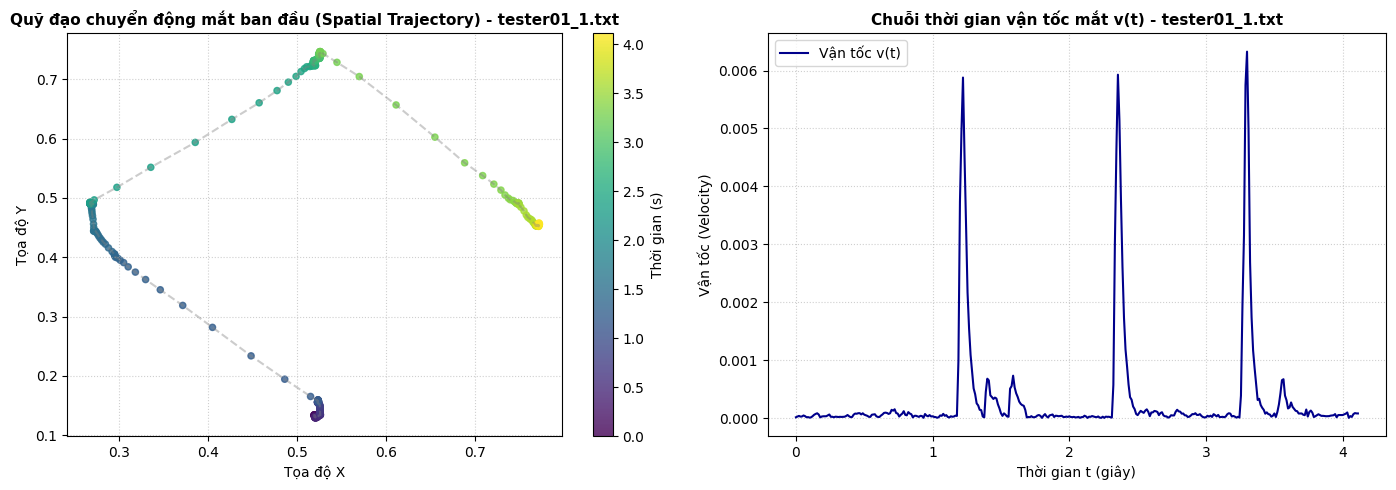

In [4]:
def load_sample_trial(dataset_dir=r'D:\cac_mon_hoc\eyemovement\dataset'):
    """Nạp 1 trial mẫu từ tập dữ liệu hoặc tạo dữ liệu mô phỏng nếu không có file."""
    txt_files = sorted(glob.glob(os.path.join(dataset_dir, 'testdataset', '*.txt')))
    if txt_files:
        txt_path = txt_files[0]
        fname = os.path.basename(txt_path)
        base_name = os.path.splitext(fname)[0]
        csv_path = os.path.join(dataset_dir, 'results', f"{base_name}_results.csv")
        
        arr = np.loadtxt(txt_path)
        df = pd.DataFrame(dict(t=np.arange(len(arr))/CFG['fs'], x=arr[:,0], y=arr[:,1], v=arr[:,2]))
        
        if os.path.exists(csv_path):
            csv_df = pd.read_csv(csv_path)
            df['label'] = csv_df['manually results'].values.astype(int)
        return df, fname
    else:
        # Dữ liệu mô phỏng tổng hợp
        rng = np.random.default_rng(42)
        n = 300
        t = np.linspace(0, 3.3, n)
        x = np.sin(t) + rng.normal(0, 0.02, n)
        y = np.cos(t) + rng.normal(0, 0.02, n)
        v = np.r_[0, np.sqrt(np.diff(x)**2 + np.diff(y)**2)]
        df = pd.DataFrame(dict(t=t, x=x, y=y, v=v, label=np.zeros(n, dtype=int)))
        return df, "synthetic_sample.txt"

df_sample, sample_fname = load_sample_trial()
print(f"Đã nạp file mẫu đại diện: {sample_fname} - Số điểm dữ liệu: {len(df_sample)}")

# Trực quan hóa dữ liệu thô ban đầu
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Quỹ đạo không gian (x, y)
sc = axs[0].scatter(df_sample['x'], df_sample['y'], c=df_sample['t'], cmap='viridis', s=20, alpha=0.8)
axs[0].plot(df_sample['x'], df_sample['y'], color='gray', linestyle='--', alpha=0.4)
axs[0].set_title(f"Quỹ đạo chuyển động mắt ban đầu (Spatial Trajectory) - {sample_fname}", fontsize=11, fontweight='bold')
axs[0].set_xlabel("Tọa độ X")
axs[0].set_ylabel("Tọa độ Y")
axs[0].grid(True, linestyle=':', alpha=0.6)
cbar = fig.colorbar(sc, ax=axs[0])
cbar.set_label("Thời gian (s)")

# 2. Chuỗi thời gian vận tốc v(t)
axs[1].plot(df_sample['t'], df_sample['v'], color='darkblue', linewidth=1.5, label='Vận tốc v(t)')
axs[1].set_title(f"Chuỗi thời gian vận tốc mắt v(t) - {sample_fname}", fontsize=11, fontweight='bold')
axs[1].set_xlabel("Thời gian t (giây)")
axs[1].set_ylabel("Vận tốc (Velocity)")
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend()

plt.tight_layout()
plt.show()

## 2. Step 0 - Chọn số đoạn tối ưu *$k$* bằng K-means SSE và Elbow (Algorithm 1)
Với mỗi số cụm $k = 1 \dots K_{max}$, thuật toán thực hiện K-Means trên tập dữ liệu và tính tổng bình phương lỗi gián đoạn $SSE = \sum_{i=1}^k \sum_{p \in C_i} \lVert p - \mu_i \rVert^2$.
Điểm khuỷu (Elbow point) là giá trị $k$ có khoảng cách vuông góc xa nhất đến đường thẳng nối từ $k=1$ đến $k=K_{max}$.

Số đoạn tối ưu được tự động chọn k = 4


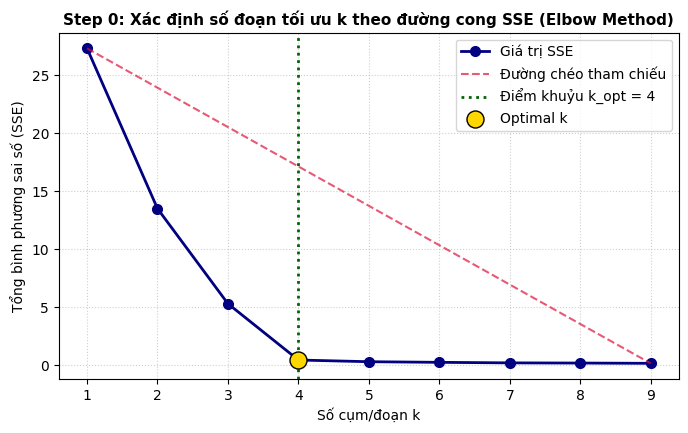

In [5]:
def kmeans_sse(X, k, max_iter, restarts, rng):
    """Tính tổng bình phương khoảng cách SSE cho k cụm K-Means."""
    best = np.inf
    for _ in range(restarts):
        mu = X[rng.choice(len(X), k, replace=False)]
        for _ in range(max_iter):
            d = ((X[:, None, :] - mu[None]) ** 2).sum(-1)
            c = d.argmin(1)
            new = np.array([X[c == i].mean(0) if (c == i).any() else mu[i] for i in range(k)])
            if np.allclose(new, mu): break
            mu = new
        sse = sum(((X[c == i] - mu[i]) ** 2).sum() for i in range(k))
        best = min(best, sse)
    return best

def find_elbow(ks, sse):
    """Tìm điểm khuỷu (Elbow point) có khoảng cách hình học lớn nhất đến đường thẳng nối 2 đầu."""
    x = (ks - ks.min()) / (ks.max() - ks.min())
    y = (sse - sse.min()) / (sse.max() - sse.min() + 1e-12)
    d = np.abs((y[-1] - y[0]) * x - (x[-1] - x[0]) * y + x[-1] * y[0] - y[-1] * x[0])
    return int(ks[d.argmax()])

def step0_optimal_k(df, cfg):
    """Thực hiện Step 0: Xác định số đoạn k tối ưu."""
    rng = np.random.default_rng(cfg['seed'])
    X = df[['x', 'y']].values
    ks = np.arange(1, min(cfg['K_MAX'], len(X) - 1) + 1)
    sse = np.array([kmeans_sse(X, k, cfg['KMEANS_MAX_ITER'], cfg['KMEANS_RESTARTS'], rng) for k in ks])
    k_opt = find_elbow(ks, sse)
    return k_opt, ks, sse

# Chạy Step 0 và vẽ biểu đồ Elbow Curve cho trial mẫu đại diện
k_opt, ks, sse = step0_optimal_k(df_sample, CFG)
print(f"Số đoạn tối ưu được tự động chọn k = {k_opt}")

# Vẽ đồ thị SSE theo k và đường Elbow
plt.figure(figsize=(8, 4.5))
plt.plot(ks, sse, 'o-', color='navy', linewidth=2, markersize=7, label='Giá trị SSE')
plt.plot([ks[0], ks[-1]], [sse[0], sse[-1]], '--', color='crimson', alpha=0.7, label='Đường chéo tham chiếu')
plt.axvline(x=k_opt, color='darkgreen', linestyle=':', linewidth=2, label=f'Điểm khuỷu k_opt = {k_opt}')
plt.scatter([k_opt], [sse[k_opt-1]], color='gold', edgecolor='black', s=150, zorder=5, label='Optimal k')
plt.title(f"Step 0: Xác định số đoạn tối ưu k theo đường cong SSE (Elbow Method)", fontsize=11, fontweight='bold')
plt.xlabel("Số cụm/đoạn k")
plt.ylabel("Tổng bình phương sai số (SSE)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

## 3. Khởi tạo & Trích xuất Mô hình GMM-HMM (Viterbi Decoding)
Sử dụng thư viện `hmmlearn` để huấn luyện GMM-HMM với các thuộc tính hiệp phương sai (spherical/full) và tìm chuỗi trạng thái ẩn tối ưu bằng thuật toán Viterbi.

In [6]:
def fit_gmmhmm(X, n_states, cfg, seed=0):
    """Huấn luyện mô hình GMM-HMM với Baum-Welch / EM và trả về mô hình có Log-Likelihood cao nhất."""
    for n_mix in dict.fromkeys([cfg['N_MIX'], 1]):
        best = None
        for r in range(cfg['N_RESTARTS']):
            try:
                m = GMMHMM(n_components=n_states, n_mix=n_mix, covariance_type=cfg['COV_TYPE'],
                           n_iter=cfg['N_ITER'], tol=cfg['TOL'], min_covar=1e-3, random_state=seed + r)
                m.fit(X)
                s = m.score(X)
                if np.isfinite(s) and (best is None or s > best[1]): best = (m, s)
            except Exception:
                continue
        if best is not None:
            return best[0]
    return None

def viterbi_states(model, X):
    """Giải mã chuỗi trạng thái ẩn bằng thuật toán Viterbi."""
    _, states = model.decode(X, algorithm="viterbi")
    return states

def _scale(X, on):
    """Chuẩn hóa dữ liệu với StandardScaler nếu bật cấu hình STANDARDIZE."""
    return StandardScaler().fit_transform(X) if on else X

## 4. Thuật toán GMM-HMM Phân cấp (Steps 1, 2, 3 - Algorithm 2)
* **Step 1 (First-level GMM-HMM):** Phân chia thô dữ liệu mắt thành $k$ đoạn sub-path dựa trên đặc trưng không gian $(x, y)$ (hoặc bổ sung vận tốc $v$).
* **Step 2 (Second-level GMM-HMM):** Thực hiện phân loại 3 trạng thái cục bộ dựa trên vận tốc $v$ trong từng đoạn sub-path.
* **Step 3 (Data Fusion & Log-Velocity Mapping):** Gom nhóm vận tốc trung bình của các trạng thái ẩn theo thang $\log_{10}$ thành 3 cụm (K-Means) và sắp xếp để gán nhãn ngữ nghĩa chuẩn: **0: Fixation (chậm nhất)**, **1: Smooth Pursuit (trung bình)**, **2: Saccade (nhanh nhất)**.

In [7]:
def hierarchical_gmm_hmm(df, cfg, k=None):
    """
    Hàm chính thực thi thuật toán GMM-HMM phân cấp 2 vòng dựa trên SSE.
    """
    N = len(df)
    # --- Step 0: Xác định k nếu chưa chỉ định
    if k is None:
        k, ks_, sse_ = step0_optimal_k(df, cfg)
        
    # --- Step 1: GMM-HMM Vòng 1 chia thành k sub-path
    X1 = _scale(df[cfg['L1_FEATURES']].values, cfg['STANDARDIZE'])
    m1 = fit_gmmhmm(X1, k, cfg, cfg['seed'])
    seg_id = viterbi_states(m1, X1)
    
    # --- Step 2: GMM-HMM Vòng 2 trong từng đoạn dựa trên vận tốc
    v = df['v'].values
    local = np.full(N, -1)
    seg_stats = []
    tiny = []
    for s in np.unique(seg_id):
        idx = np.where(seg_id == s)[0]
        if len(idx) < cfg['MIN_SEG_LEN']:
            tiny.append(idx); continue
        X2 = _scale(df.loc[idx, cfg['L2_FEATURES']].values, cfg['STANDARDIZE'])
        m2 = fit_gmmhmm(X2, 3, cfg, cfg['seed'] + 100)
        if m2 is None:
            tiny.append(idx); continue
        st = viterbi_states(m2, X2)
        local[idx] = st
        for c in np.unique(st):
            seg_stats.append((s, c, v[idx][st == c].mean()))
            
    # --- Step 3: Data Fusion & Phân nhóm nhãn ngữ nghĩa theo Log-Velocity
    lv = np.log10(np.array([m for _, _, m in seg_stats]) + 1e-6).reshape(-1, 1)
    km = KMeans(3, n_init=10, random_state=cfg['seed']).fit(lv)
    order = np.argsort(km.cluster_centers_.ravel())          # Thứ tự vận tốc từ nhỏ đến lớn
    rank = {int(c): r for r, c in enumerate(order)}          # 0: Fixation, 1: Smooth Pursuit, 2: Saccade
    centers = km.cluster_centers_.ravel()[order]
    state2label = {(s, c): rank[int(g)] for (s, c, _), g in zip(seg_stats, km.labels_)}
    
    # Tổng hợp nhãn dự đoán hoàn chỉnh
    pred = np.full(N, -1)
    for i in range(N):
        if local[i] >= 0:
            pred[i] = state2label[(seg_id[i], local[i])]
    # Đoạn quá ngắn (tiny): gán theo tâm vận tốc gần nhất
    for idx in tiny:
        d = np.abs(np.log10(v[idx] + 1e-6)[:, None] - centers[None])
        pred[idx] = d.argmin(1)
        
    return dict(k=k, seg_id=seg_id, pred=pred, centers=10 ** centers, n_tiny=len(tiny))

# Chạy phân loại trên trial mẫu đại diện
res_sample = hierarchical_gmm_hmm(df_sample, CFG, k=k_opt)
print(f"Phân loại trial mẫu thành công | k = {res_sample['k']} | Tâm vận tốc: {np.round(res_sample['centers'], 5)}")

Phân loại trial mẫu thành công | k = 4 | Tâm vận tốc: [5.00e-05 3.40e-04 2.85e-03]


## 5. Sơ đồ Quy trình Thuật toán GMM-HMM Phân cấp (Pipeline Flowchart)
Sơ đồ dưới đây tổng hợp trực quan toàn bộ kiến trúc 4 bước của mô hình GMM-HMM phân cấp dựa trên SSE (Xie et al. 2025).

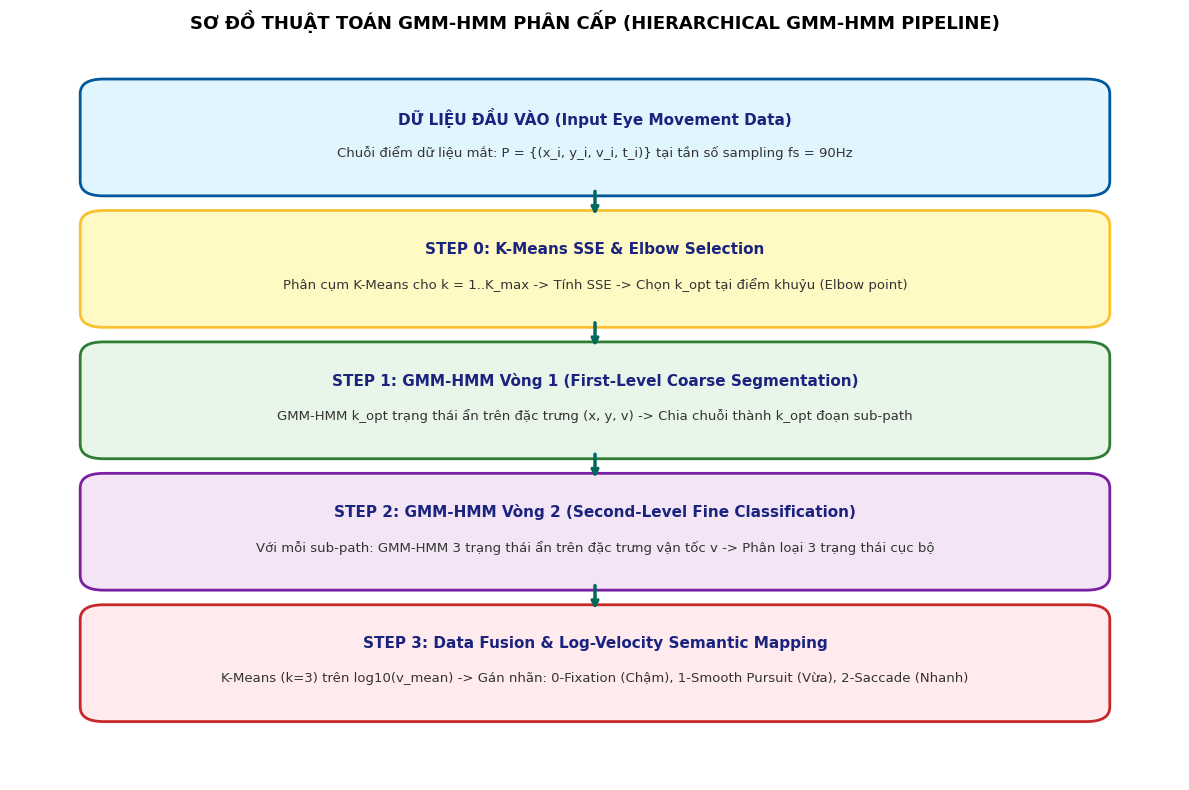

In [8]:
# Trực quan hóa sơ đồ khối quy trình xử lý của thuật toán
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

boxes = [
    dict(box=(0.8, 8.2, 8.4, 1.2), color='#E1F5FE', ec='#01579B', title="DỮ LIỆU ĐẦU VÀO (Input Eye Movement Data)", text="Chuỗi điểm dữ liệu mắt: P = {(x_i, y_i, v_i, t_i)} tại tần số sampling fs = 90Hz"),
    dict(box=(0.8, 6.4, 8.4, 1.2), color='#FFF9C4', ec='#FBC02D', title="STEP 0: K-Means SSE & Elbow Selection", text="Phân cụm K-Means cho k = 1..K_max -> Tính SSE -> Chọn k_opt tại điểm khuỷu (Elbow point)"),
    dict(box=(0.8, 4.6, 8.4, 1.2), color='#E8F5E9', ec='#2E7D32', title="STEP 1: GMM-HMM Vòng 1 (First-Level Coarse Segmentation)", text="GMM-HMM k_opt trạng thái ẩn trên đặc trưng (x, y, v) -> Chia chuỗi thành k_opt đoạn sub-path"),
    dict(box=(0.8, 2.8, 8.4, 1.2), color='#F3E5F5', ec='#7B1FA2', title="STEP 2: GMM-HMM Vòng 2 (Second-Level Fine Classification)", text="Với mỗi sub-path: GMM-HMM 3 trạng thái ẩn trên đặc trưng vận tốc v -> Phân loại 3 trạng thái cục bộ"),
    dict(box=(0.8, 1.0, 8.4, 1.2), color='#FFEBEE', ec='#C62828', title="STEP 3: Data Fusion & Log-Velocity Semantic Mapping", text="K-Means (k=3) trên log10(v_mean) -> Gán nhãn: 0-Fixation (Chậm), 1-Smooth Pursuit (Vừa), 2-Saccade (Nhanh)")
]

for b in boxes:
    x, y, w, h = b['box']
    rect = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.2", facecolor=b['color'], edgecolor=b['ec'], linewidth=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h*0.72, b['title'], ha='center', va='center', fontsize=11, fontweight='bold', color='#1A237E')
    ax.text(x + w/2, y + h*0.32, b['text'], ha='center', va='center', fontsize=9.5, color='#333333')

# Mũi tên kết nối giữa các khối
for i in range(len(boxes) - 1):
    y_start = boxes[i]['box'][1]
    y_end = boxes[i+1]['box'][1] + boxes[i+1]['box'][3]
    ax.annotate('', xy=(5.0, y_end + 0.1), xytext=(5.0, y_start - 0.1),
                arrowprops=dict(arrowstyle="->", lw=2.5, color='#00695C'))

plt.title("SƠ ĐỒ THUẬT TOÁN GMM-HMM PHÂN CẤP (HIERARCHICAL GMM-HMM PIPELINE)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Đánh giá Tổng thể & Trực quan hóa Kết quả Toàn bộ 87 Trial của Dataset
Chạy kiểm thử tự động thuật toán GMM-HMM phân cấp trên toàn bộ 87 trial trong thư mục `testdataset` và trực quan hóa ma trận nhầm lẫn tổng tích lũy cùng phân bố độ chính xác.

Bắt đầu đánh giá trên toàn bộ 87 file dữ liệu...



--- ĐÁNH GIÁ TỔNG THỂ TRÊN TOÀN BỘ 87 TRIAL CỦA DATASET ---
Accuracy trung bình           = 0.8745 +/- 0.0805
Precision trung bình (Macro)  = 0.8564 +/- 0.0744
Recall trung bình (Macro)     = 0.8472 +/- 0.1059
F1-Score trung bình (Macro)   = 0.8355 +/- 0.1050

--- CHI TIẾT ĐÁNH GIÁ TỪNG LỚP TRẠNG THÁI (PER-CLASS METRICS) ---
Fixation      : Precision = 0.9427, Recall = 0.9238, F1-Score = 0.9277
Smooth Pursuit: Precision = 0.7385, Recall = 0.8040, F1-Score = 0.7563
Saccade       : Precision = 0.8880, Recall = 0.8138, F1-Score = 0.8226


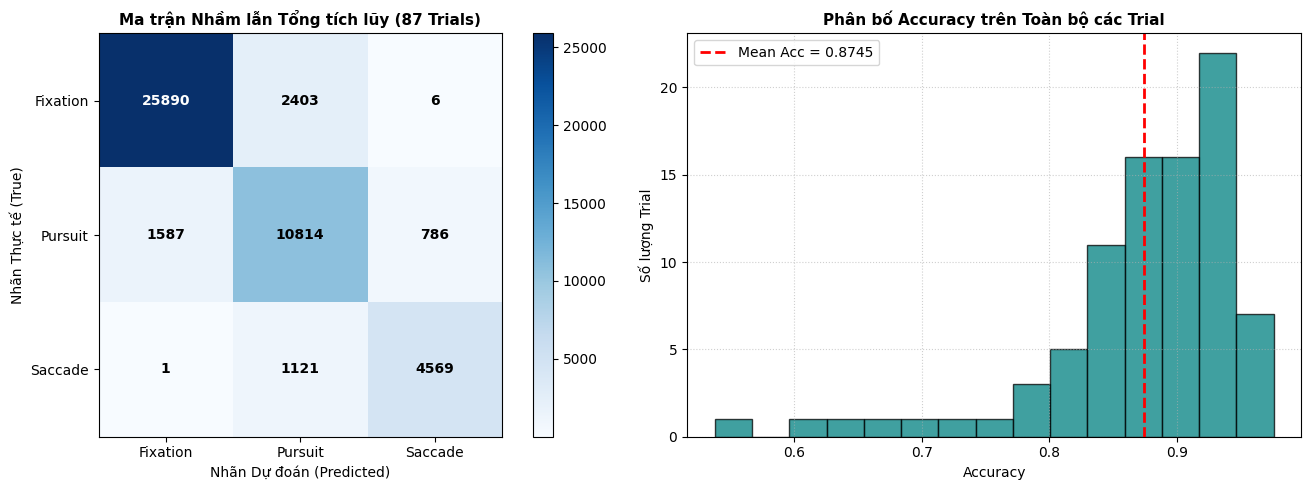

In [10]:
# Đường dẫn thư mục tập dữ liệu
dataset_dir = r'D:\cac_mon_hoc\eyemovement\dataset'
txt_files = sorted(glob.glob(os.path.join(dataset_dir, 'testdataset', '*.txt')))
res_dir = os.path.join(dataset_dir, 'results')

results = []
all_y_true = []
all_y_pred = []

print(f"Bắt đầu đánh giá trên toàn bộ {len(txt_files)} file dữ liệu...")
for txt_path in txt_files:
    fname = os.path.basename(txt_path)
    base_name = os.path.splitext(fname)[0]
    csv_path = os.path.join(res_dir, f"{base_name}_results.csv")
    
    if not os.path.exists(csv_path):
        continue
        
    arr = np.loadtxt(txt_path)
    csv_df = pd.read_csv(csv_path)
    
    df = pd.DataFrame(dict(t=np.arange(len(arr))/CFG['fs'], x=arr[:,0], y=arr[:,1], v=arr[:,2]))
    y_true = csv_df['manually results'].values.astype(int)
    
    try:
        out = hierarchical_gmm_hmm(df, CFG)
        y_pred = out['pred']
        
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
        
        acc = accuracy_score(y_true, y_pred)
        p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[FIX, PUR, SAC], zero_division=0)
        
        results.append({
            'file': fname,
            'k': out['k'],
            'acc': acc,
            'p_fix': p[0], 'r_fix': r[0], 'f_fix': f[0],
            'p_pur': p[1], 'r_pur': r[1], 'f_pur': f[1],
            'p_sac': p[2], 'r_sac': r[2], 'f_sac': f[2],
            'p_macro': p.mean(), 'r_macro': r.mean(), 'f_macro': f.mean()
        })
    except Exception as e:
        print(f"Lỗi xử lý file {fname}: {e}")

# Tổng hợp và in báo cáo kết quả
res_df = pd.DataFrame(results)
print("\n" + "="*60)
print(f"--- ĐÁNH GIÁ TỔNG THỂ TRÊN TOÀN BỘ {len(res_df)} TRIAL CỦA DATASET ---")
print("="*60)
print(f"Accuracy trung bình           = {res_df['acc'].mean():.4f} +/- {res_df['acc'].std():.4f}")
print(f"Precision trung bình (Macro)  = {res_df['p_macro'].mean():.4f} +/- {res_df['p_macro'].std():.4f}")
print(f"Recall trung bình (Macro)     = {res_df['r_macro'].mean():.4f} +/- {res_df['r_macro'].std():.4f}")
print(f"F1-Score trung bình (Macro)   = {res_df['f_macro'].mean():.4f} +/- {res_df['f_macro'].std():.4f}")

print("\n--- CHI TIẾT ĐÁNH GIÁ TỪNG LỚP TRẠNG THÁI (PER-CLASS METRICS) ---")
print(f"Fixation      : Precision = {res_df['p_fix'].mean():.4f}, Recall = {res_df['r_fix'].mean():.4f}, F1-Score = {res_df['f_fix'].mean():.4f}")
print(f"Smooth Pursuit: Precision = {res_df['p_pur'].mean():.4f}, Recall = {res_df['r_pur'].mean():.4f}, F1-Score = {res_df['f_pur'].mean():.4f}")
print(f"Saccade       : Precision = {res_df['p_sac'].mean():.4f}, Recall = {res_df['r_sac'].mean():.4f}, F1-Score = {res_df['f_sac'].mean():.4f}")
print("="*60)

# Trực quan hóa Ma trận nhầm lẫn Tổng tích lũy cho toàn bộ Dataset
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix Tổng tích lũy
total_cm = confusion_matrix(all_y_true, all_y_pred, labels=[FIX, PUR, SAC])
im = axs[0].imshow(total_cm, interpolation='nearest', cmap=plt.cm.Blues)
axs[0].set_title(f"Ma trận Nhầm lẫn Tổng tích lũy ({len(res_df)} Trials)", fontsize=11, fontweight='bold')
fig.colorbar(im, ax=axs[0])
tick_marks = np.arange(3)
axs[0].set_xticks(tick_marks)
axs[0].set_xticklabels(['Fixation', 'Pursuit', 'Saccade'])
axs[0].set_yticks(tick_marks)
axs[0].set_yticklabels(['Fixation', 'Pursuit', 'Saccade'])
axs[0].set_ylabel('Nhãn Thực tế (True)')
axs[0].set_xlabel('Nhãn Dự đoán (Predicted)')
for i in range(3):
    for j in range(3):
        axs[0].text(j, i, format(total_cm[i, j], 'd'), ha="center", va="center",
                 color="white" if total_cm[i, j] > total_cm.max() / 2. else "black", fontweight='bold')

# 2. Phân bố Accuracy trên toàn bộ 87 trials
axs[1].hist(res_df['acc'], bins=15, color='teal', edgecolor='black', alpha=0.75)
axs[1].axvline(x=res_df['acc'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean Acc = {res_df['acc'].mean():.4f}")
axs[1].set_title("Phân bố Accuracy trên Toàn bộ các Trial", fontsize=11, fontweight='bold')
axs[1].set_xlabel("Accuracy")
axs[1].set_ylabel("Số lượng Trial")
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend()

plt.tight_layout()
plt.show()